In [1]:
import asdf
import dkist
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [2]:
l2 = asdf.open("/Users/seanhess/Data/level2/generated/pid_1_118/inv.SD9T3L/INV_SD9T3L_L2.asdf")
quantities = l2["inversion"]["quantities"]

profiles = l2["inversion"]["profiles"]
l2.info()

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): DKIST Data Center
│ ├─homepage (str): https://github.com/dkistdc/telescope.hs
│ ├─name (str): telescope.hs
│ └─version (str): 0.2.0
├─history (dict)
│ └─extensions (list): []
└─inversion (dict)
  ├─fileuris (list)
  │ ├─[0] (str): INV_SD9T3L_2022_06_02T21_47_36_373_L2.fits
  │ ├─[1] (str): INV_SD9T3L_2022_06_02T21_47_39_662_L2.fits
  │ ├─[2] (str): INV_SD9T3L_2022_06_02T21_47_42_950_L2.fits
  │ ├─[3] (str): INV_SD9T3L_2022_06_02T21_47_46_238_L2.fits
  │ ├─[4] (str): INV_SD9T3L_2022_06_02T21_47_49_527_L2.fits
  │ ├─[5] (str): INV_SD9T3L_2022_06_02T21_47_52_815_L2.fits
  │ ├─[6] (str): INV_SD9T3L_2022_06_02T21_47_56_104_L2.fits
  │ ├─[7] (str): INV_SD9T3L_2022_06_02T21_47_59_392_L2.fits
  │ ├─[8] (str): INV_SD9T3L_2022_06_02T21_48_02_681_L2.fits
  │ └─477 not shown
  ├─meta (dict) ...
  ├─quantities (dict) ...
  └─profiles (dict) ...
Some nodes not shown.


In [3]:
# Optical Depth incorrect

tau0 = 11
tau27 = 38

wcs = l2["inversion"]["quantities"]["wcs"]
wcs.pixel_to_world(tau27,0,0)
wcs(tau27,0,0)
wcs(0,200,400)

(1.1, 359.9382336166229, -0.09013971150320592)

In [4]:
opticalDepth = quantities["opticalDepth"]["data"]._generate_array()
temperature = quantities["temperature"]["data"]._generate_array()
electronPressure = quantities["electronPressure"]["data"]._generate_array()
microTurbulence = quantities["microTurbulence"]["data"]._generate_array()
velocity = quantities["velocity"]["data"]._generate_array()
magStrength = quantities["magStrength"]["data"]._generate_array()
magInclination = quantities["magInclination"]["data"]._generate_array()
magAzimuth = quantities["magAzimuth"]["data"]._generate_array()
geoHeight = quantities["geoHeight"]["data"]._generate_array()
gasPressure = quantities["gasPressure"]["data"]._generate_array()
density = quantities["density"]["data"]._generate_array()

In [5]:
opticalDepth.shape

(486, 237, 81)


print(opticalDepth[tau27,:,:].shape)

plt.imshow(opticalDepth[tau27,:,:].transpose())
plt.colorbar(label='Optical Depth = Tau')
plt.show()

In [6]:
# Comparable L1 Graph
l1 = asdf.open("/Users/seanhess/Data/pid_1_118/id.85415.1029535/BWKXP/VISP_L1_20220602T214726_BWKXP.asdf")
ds = l1["dataset"]
print(ds.data.shape)
print(ds[0,:,0,:].data.shape)
ds.plot(plot_axes=[None, 'x', None, 'y'])
plt.show()
#ds.plot(plot_axes=[None, 'y', None, 'x'])
#ds[0,:,0,:].plot()
#plt.show()

#plt.figure(figsize=(10, 8))
#plt.subplot(projection=l1_gwcs, slices=('x', 0,'y', 0))
#plt.imshow(l1["dataset"].data[0,:,0,:])
#plt.show()

(4, 490, 998, 2538)
(490, 2538)


/Users/seanhess/.pyenv/versions/3.10.5/envs/notebooks/lib/python3.10/site-packages/ndcube/visualization/mpl_plotter.py:255: UserWarning: Animating a NDCube does not support transposing the array. The world axes may not display as expected because the array will not be transposed.
  warnings.warn(


ValueError: Image size of 3404675x448 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 5 Axes>

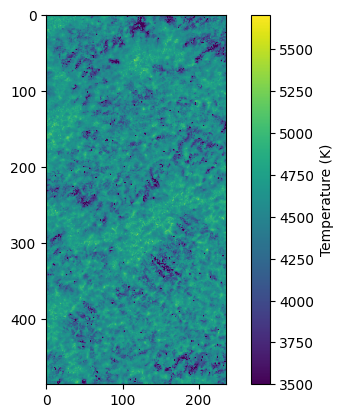

In [16]:
l2 = asdf.open("INV_SD9T3L_L2.asdf")
quantities = l2["inversion"]["quantities"]
temperature = quantities["temperature"]["data"]._generate_array()
plt.imshow(temperature[:,:,tau27], vmin=3500)
plt.colorbar(label='Temperature (K)')
plt.show()

(486, 237)


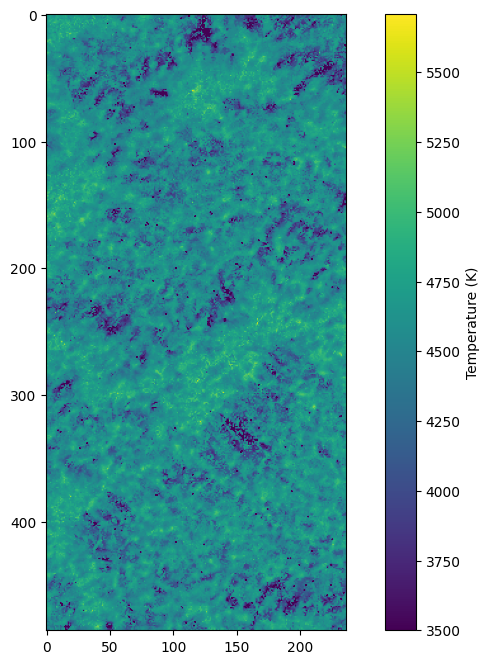

In [9]:
print(temperature[:,:,tau27].shape)
plt.figure(figsize=(10, 8))

#plt.subplot(projection=wcs, slices=(tau27, 'y','x'))
#plt.subplot(projection=wcs, slices=(tau27, 'y','x'))

plt.imshow(temperature[:,:,tau27], vmin=3500)

plt.colorbar(label='Temperature (K)')

plt.show()

(486, 237)


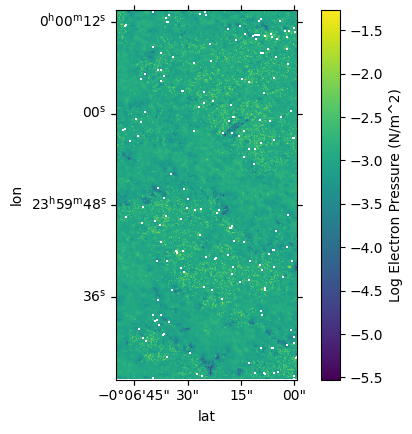

In [288]:
print(electronPressure[:,:,tau27].shape)

plt.subplot(projection=wcs, slices=(tau27, 'y','x'))
plt.imshow(np.log(electronPressure[:,:,tau27]))

plt.colorbar(label='Log Electron Pressure (N/m^2)')
plt.show()

#print(electronPressure[:,:,tau27].compute())

(486, 237)


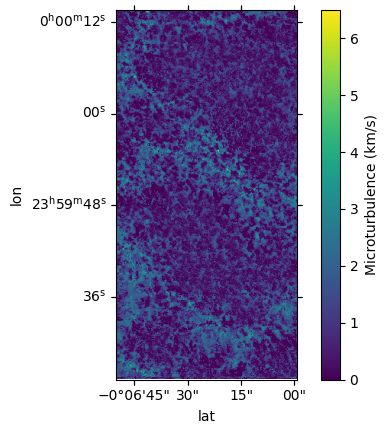

In [245]:
print(microTurbulence[:,:,tau27].shape)

plt.subplot(projection=wcs, slices=(tau27, 'y','x'))
plt.imshow(microTurbulence[:,:,tau27])

plt.colorbar(label='Microturbulence (km/s)')
plt.show()

(486, 237)


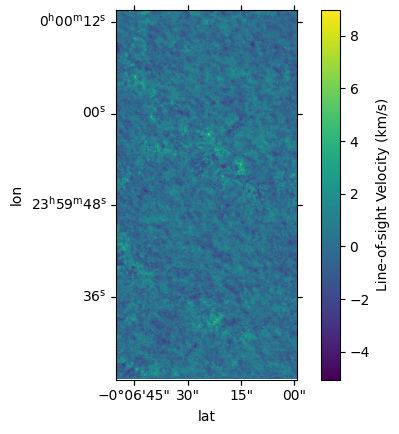

In [246]:
print(velocity[:,:,tau27].shape)

plt.subplot(projection=wcs, slices=(tau27, 'y','x'))
plt.imshow(velocity[:,:,tau27])

plt.colorbar(label='Line-of-sight Velocity (km/s)')
plt.show()

(486, 237)


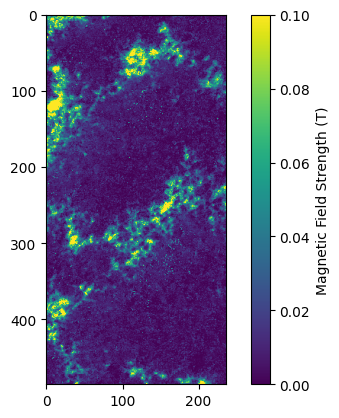

In [10]:
print(magStrength[:,:,tau27].shape)

#plt.subplot(projection=wcs, slices=(tau27, 'y','x'))
plt.imshow(magStrength[:,:,tau27], vmax=0.1)

plt.colorbar(label='Magnetic Field Strength (T)')
plt.show()

(486, 237)


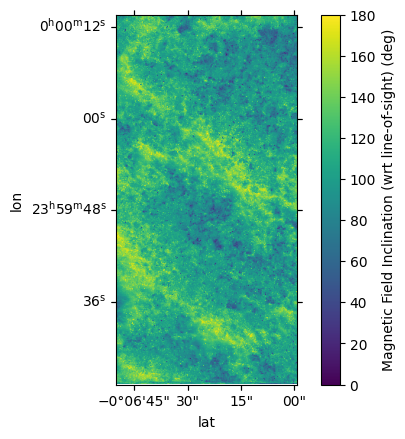

In [254]:
print(magInclination[:,:,tau27].shape)

plt.subplot(projection=wcs, slices=(tau27, 'y','x'))
plt.imshow(magInclination[:,:,tau27], vmin=0, vmax=180)

plt.colorbar(label='Magnetic Field Inclination (wrt line-of-sight) (deg)')
plt.show()

(486, 237)


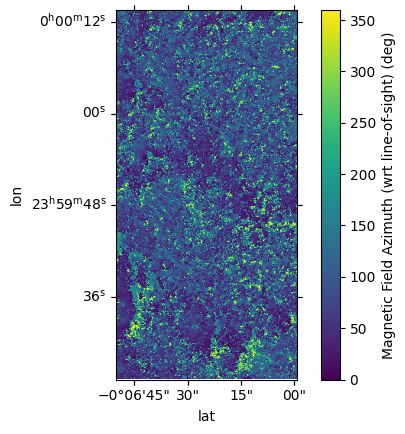

In [347]:
# TODO: negative values +360

print(magAzimuth[:,:,tau27].shape)

plt.subplot(projection=wcs, slices=(tau27, 'y','x'))
plt.imshow(magAzimuth[:,:,tau27])

plt.colorbar(label='Magnetic Field Azimuth (wrt line-of-sight) (deg)')
plt.show()

(486, 237)


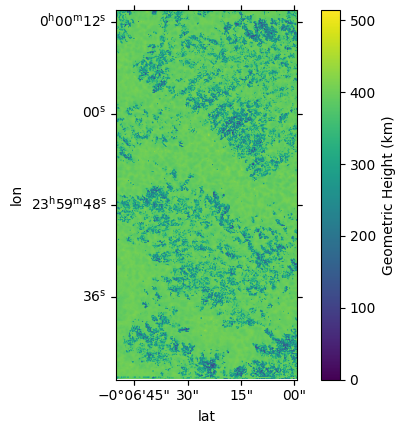

In [260]:
print(geoHeight[:,:,tau27].shape)

plt.subplot(projection=wcs, slices=(tau27, 'y','x'))
plt.imshow(geoHeight[:,:,tau27])

plt.colorbar(label='Geometric Height (km)')
plt.show()

(486, 237)


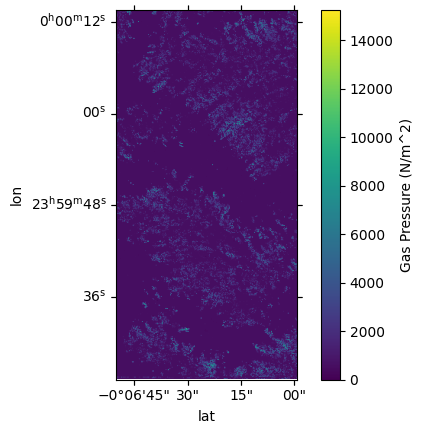

In [267]:
print(gasPressure[:,:,tau27].shape)

plt.subplot(projection=wcs, slices=(tau27, 'y','x'))
plt.imshow(gasPressure[:,:,tau27])

plt.colorbar(label='Gas Pressure (N/m^2)')
plt.show()

(486, 237)


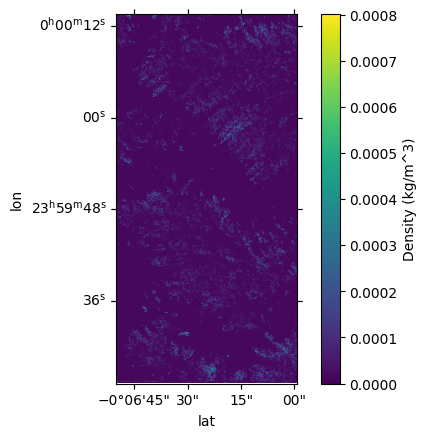

In [269]:
print(density[:,:,tau27].shape)

plt.subplot(projection=wcs, slices=(tau27, 'y','x'))
plt.imshow(density[:,:,tau27])

plt.colorbar(label='Density (kg/m^3)')
plt.show()

In [470]:
profiles = l2["inversion"]["profiles"]
fit630 = profiles["fit"]["wav6302"]["data"]._generate_array()
fit854 = profiles["fit"]["wav8542"]["data"]._generate_array()
orig630 = profiles["original"]["wav6302"]["data"]._generate_array()
orig854 = profiles["original"]["wav8542"]["data"]._generate_array()
pwcs = profiles["wcs"]

stokesI = 0

(486, 237, 150, 4)


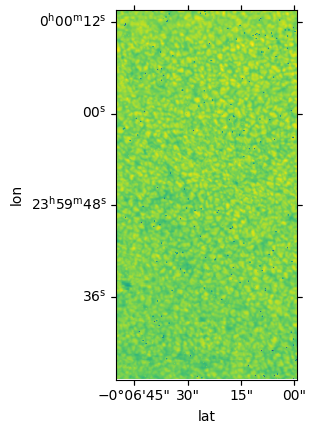

In [471]:
print(fit630.shape)
plt.subplot(projection=pwcs, slices=(stokesI, 0, 'y','x'))
plt.imshow(fit630[:,:,0,stokesI])

(486, 237, 150, 4)


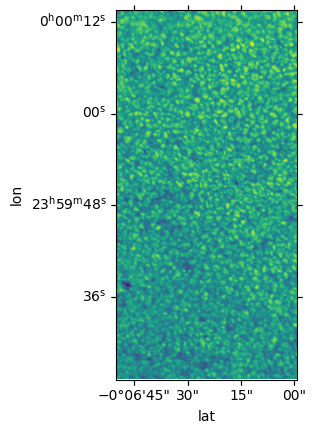

In [472]:
print(orig630.shape)
plt.subplot(projection=pwcs, slices=(stokesI, 0, 'y','x'))
plt.imshow(orig630[:,:,0,stokesI])

(486, 237, 500, 4)


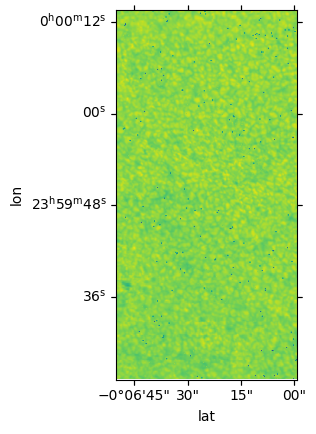

In [473]:
print(fit854.shape)
plt.subplot(projection=pwcs, slices=(stokesI, 0, 'y','x'))
plt.imshow(fit854[:,:,0,stokesI])

(486, 237, 500, 4)


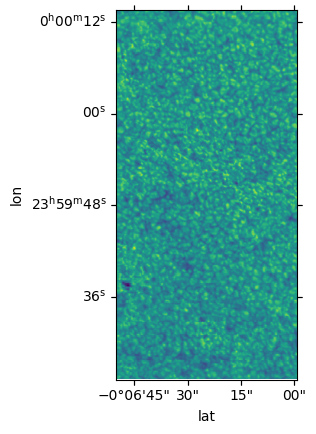

In [474]:
print(orig854.shape)
plt.subplot(projection=pwcs, slices=(stokesI, 0, 'y','x'))
plt.imshow(orig854[:,:,0,stokesI])